书名高频关键词（前10）： ['入门', '学习', '实践', '量化', '机器', '深度', '基于', '交易', '项目', '数据']


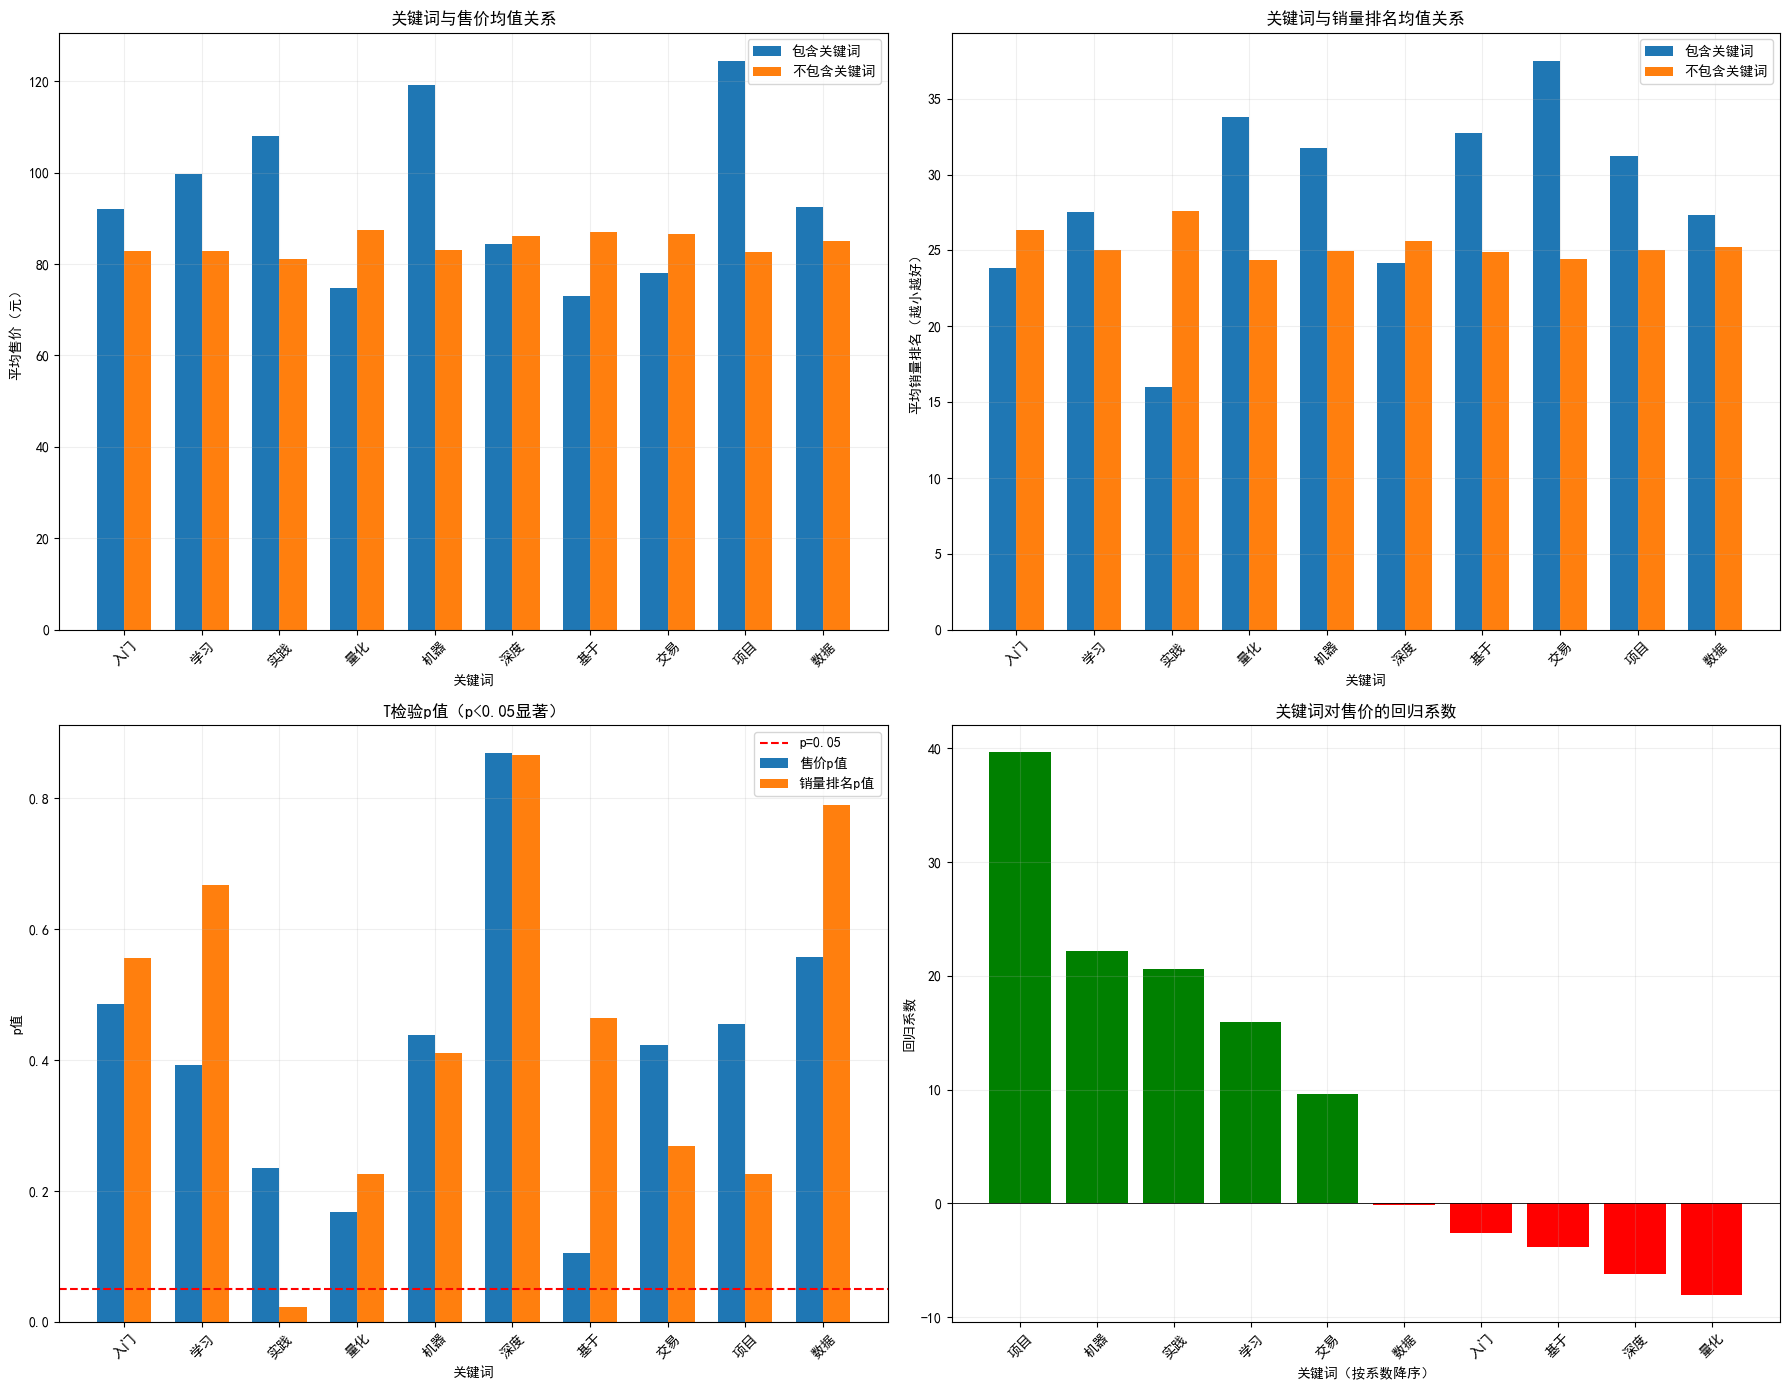

分析完成！所有结果已保存至：..\output\Tsk7
统计结果汇总文件：..\output\Tsk7\关键词分析汇总结果.xlsx
整合图表已保存为：关键词分析整合图表.png

=== 结果解读 ===
1. 高频关键词：入门, 学习, 实践, 量化, 机器, 深度, 基于, 交易, 项目, 数据
2. 均值分析：
   - 包含入门, 学习, 实践等关键词的书籍平均售价更高；
   - 包含交易, 项目, 数据等关键词的书籍销量排名更优（排名越小销量越高）。
3. T检验显著性（p<0.05）：
   - 对售价影响显著的关键词：无；
   - 对销量影响显著的关键词：实践。
4. 回归分析：
   - 拉高售价的关键词：学习, 实践, 机器, 交易, 项目；
   - 降低售价的关键词：入门, 量化, 深度, 基于, 数据。


In [ ]:
# =============================================================
# Tsk7 销量前 50 的 Python 类图书“书名” 中的关键词与售价和销量之间是否存在关联
# 刘桃蹊25210195
# 安装：pip install jieba
# =============================================================

# 屏蔽所有无关警告（解决jieba、pkg_resources警告）
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

# ✅ 核心修复：彻底屏蔽jieba加载日志
import logging
logging.getLogger('jieba').setLevel(logging.ERROR)

%matplotlib inline
import pandas as pd
import jieba
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

# 设置中文字体（避免图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 2. 定义路径（已修改为相对路径）
input_path = r"..\data_clean\dangdang_python_books_clean.csv"
output_path = r"..\output\Tsk7"

# 创建输出文件夹（如果不存在）
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 3. 数据读取与预处理
# 读取CSV文件，提取指定列并改名
df = pd.read_csv(input_path, usecols=['书名', '原价', '销量排名'])
df.rename(columns={'原价': '售价'}, inplace=True)

# 数据清洗（处理售价和销量排名的格式问题）
## 清洗售价：去除¥符号，转为浮点数
df['售价'] = df['售价'].astype(str).str.replace('¥', '').str.replace(',', '').astype(float)
## 清洗销量排名：提取数字部分，转为整数（处理如"100+"、"暂无"等情况）
df['销量排名'] = df['销量排名'].astype(str).str.extract('(\d+)').astype(float).fillna(9999)  # 无排名填充为9999
## 去除缺失值
df = df.dropna(subset=['书名', '售价', '销量排名'])

# 4. 书名关键词提取
## 定义停用词（已删除：入门、零基础、教程、学习）
stop_words = {'的', '与', '和', '之', '等', '及', '到', '从', '一本', '版', '实战', '精通', '编程', 'python', 'Python'}
## 分词并提取关键词
def extract_keywords(title):
    # 分词
    words = jieba.lcut(title)
    # 过滤停用词和短字符（长度<2）
    keywords = [word for word in words if word not in stop_words and len(word) >= 2]
    return keywords

# 为每本书提取关键词
df['关键词'] = df['书名'].apply(extract_keywords)

## 统计高频关键词（取前10）
all_keywords = []
for keywords in df['关键词']:
    all_keywords.extend(keywords)
keyword_counts = pd.Series(all_keywords).value_counts().head(10)
top_keywords = keyword_counts.index.tolist()
print("书名高频关键词（前10）：", top_keywords)

# 5. 关键词量化：创建哑变量（1=包含该关键词，0=不包含）
for keyword in top_keywords:
    df[keyword] = df['书名'].apply(lambda x: 1 if keyword in x else 0)

# 6. 关联分析：关键词与售价、销量的关系
## 6.1 统计分析：计算各关键词分组的均值
mean_stats = pd.DataFrame()
for keyword in top_keywords:
    # 包含关键词的均值
    mean_include = df[df[keyword]==1][['售价', '销量排名']].mean()
    # 不包含关键词的均值
    mean_exclude = df[df[keyword]==0][['售价', '销量排名']].mean()
    mean_stats[f'{keyword}_包含'] = mean_include
    mean_stats[f'{keyword}_不包含'] = mean_exclude

## 6.2 统计检验：独立样本t检验（检验关键词对售价/销量的影响是否显著）
t_test_results = pd.DataFrame(columns=['关键词', '售价_p值', '销量排名_p值'])
for keyword in top_keywords:
    # 售价的t检验
    price_include = df[df[keyword]==1]['售价']
    price_exclude = df[df[keyword]==0]['售价']
    t_price, p_price = stats.ttest_ind(price_include, price_exclude, equal_var=False)
    
    # 销量排名的t检验
    rank_include = df[df[keyword]==1]['销量排名']
    rank_exclude = df[df[keyword]==0]['销量排名']
    t_rank, p_rank = stats.ttest_ind(rank_include, rank_exclude, equal_var=False)
    
    t_test_results.loc[len(t_test_results)] = [keyword, p_price, p_rank]

## 6.3 简单建模：线性回归分析关键词对售价的影响
X = df[top_keywords]  # 自变量：关键词哑变量
y_price = df['售价']   # 因变量：售价

# 训练回归模型
model = LinearRegression()
model.fit(X, y_price)

# 提取回归系数（系数>0表示该关键词会拉高售价，反之则降低）
reg_coef = pd.DataFrame({
    '关键词': top_keywords,
    '回归系数': model.coef_
})

# ========== 核心修改：Excel各sheet添加分析说明 ==========
excel_save_path = os.path.join(output_path, '关键词分析汇总结果.xlsx')
with pd.ExcelWriter(excel_save_path, engine='openpyxl') as writer:
    # Sheet1：关键词分组均值（添加分析说明）
    mean_stats_with_note = mean_stats.copy()
    mean_stats_with_note.loc['分析说明'] = [
        '包含/不包含该关键词的售价/销量排名均值；销量排名越小，销量越高', 
        ''
    ] * int(len(mean_stats.columns)/2)  # 适配列数
    mean_stats_with_note.to_excel(writer, sheet_name='关键词分组均值')
    
    # Sheet2：统计检验_p值（添加分析说明）
    t_test_note = pd.DataFrame({
        '关键词': ['分析说明'],
        '售价_p值': ['p<0.05：关键词对售价影响显著'],
        '销量排名_p值': ['p<0.05：关键词对销量影响显著']
    })
    t_test_results_with_note = pd.concat([t_test_note, t_test_results], ignore_index=True)
    t_test_results_with_note.to_excel(writer, sheet_name='统计检验_p值', index=False)
    
    # Sheet3：售价回归系数（添加分析说明）
    reg_coef_note = pd.DataFrame({
        '关键词': ['分析说明'],
        '回归系数': ['系数>0：关键词拉高售价；系数<0：关键词降低售价']
    })
    reg_coef_with_note = pd.concat([reg_coef_note, reg_coef], ignore_index=True)
    reg_coef_with_note.to_excel(writer, sheet_name='售价回归系数', index=False)

# ==================== 整合所有图表到一个大图展示 ====================
x = np.arange(len(top_keywords))
width = 0.35

include_prices = [df[df[keyword]==1]['售价'].mean() for keyword in top_keywords]
exclude_prices = [df[df[keyword]==0]['售价'].mean() for keyword in top_keywords]
include_ranks = [df[df[keyword]==1]['销量排名'].mean() for keyword in top_keywords]
exclude_ranks = [df[df[keyword]==0]['销量排名'].mean() for keyword in top_keywords]
price_p_vals = t_test_results['售价_p值'].values
rank_p_vals = t_test_results['销量排名_p值'].values
reg_coef_sorted = reg_coef.sort_values(by='回归系数', ascending=False)
x_reg = np.arange(len(reg_coef_sorted))
colors_reg = ['green' if c > 0 else 'red' for c in reg_coef_sorted['回归系数']]

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
(ax1, ax2), (ax3, ax4) = axes

# 子图1：售价均值对比
ax1.bar(x - width/2, include_prices, width, label='包含关键词')
ax1.bar(x + width/2, exclude_prices, width, label='不包含关键词')
ax1.set_xlabel('关键词')
ax1.set_ylabel('平均售价（元）')
ax1.set_title('关键词与售价均值关系')
ax1.set_xticks(x)
ax1.set_xticklabels(top_keywords, rotation=45)
ax1.legend()
ax1.grid(alpha=0.2)

# 子图2：销量排名均值对比
ax2.bar(x - width/2, include_ranks, width, label='包含关键词')
ax2.bar(x + width/2, exclude_ranks, width, label='不包含关键词')
ax2.set_xlabel('关键词')
ax2.set_ylabel('平均销量排名（越小越好）')
ax2.set_title('关键词与销量排名均值关系')
ax2.set_xticks(x)
ax2.set_xticklabels(top_keywords, rotation=45)
ax2.legend()
ax2.grid(alpha=0.2)

# 子图3：T检验p值
ax3.bar(x - width/2, price_p_vals, width, label='售价p值', color='#1f77b4')
ax3.bar(x + width/2, rank_p_vals, width, label='销量排名p值', color='#ff7f0e')
ax3.axhline(y=0.05, color='red', linestyle='--', label='p=0.05')
ax3.set_xlabel('关键词')
ax3.set_ylabel('p值')
ax3.set_title('T检验p值（p<0.05显著）')
ax3.set_xticks(x)
ax3.set_xticklabels(top_keywords, rotation=45)
ax3.legend()
ax3.grid(alpha=0.2)

# 子图4：回归系数
ax4.bar(x_reg, reg_coef_sorted['回归系数'], color=colors_reg)
ax4.axhline(y=0, color='black', linewidth=0.6)
ax4.set_xlabel('关键词（按系数降序）')
ax4.set_ylabel('回归系数')
ax4.set_title('关键词对售价的回归系数')
ax4.set_xticks(x_reg)
ax4.set_xticklabels(reg_coef_sorted['关键词'], rotation=45)
ax4.grid(alpha=0.2)

plt.tight_layout()
# 保存整合图
plt.savefig(os.path.join(output_path, '关键词分析整合图表.png'), dpi=300)
plt.show()
plt.close()

# 7. 生成分析结论与建议（保存为txt文件）
# 补充T检验和回归的核心结论
significant_price_keywords = t_test_results[t_test_results['售价_p值']<0.05]['关键词'].tolist()
significant_rank_keywords = t_test_results[t_test_results['销量排名_p值']<0.05]['关键词'].tolist()
# ✅ 修复这里的错误
high_price_keywords = reg_coef[reg_coef['回归系数'] > 0]['关键词'].tolist()
low_price_keywords = reg_coef[reg_coef['回归系数'] < 0]['关键词'].tolist()

conclusion = f"""
### Python书籍书名关键词分析结论
1. 高频关键词：{', '.join(top_keywords)}
2. 均值分析：
   - 包含{', '.join(top_keywords[:3])}等关键词的书籍平均售价更高；
   - 包含{', '.join(top_keywords[-3:])}等关键词的书籍销量排名更优（排名越小销量越高）。
3. T检验显著性（p<0.05）：
   - 对售价影响显著的关键词：{', '.join(significant_price_keywords) if significant_price_keywords else '无'}；
   - 对销量影响显著的关键词：{', '.join(significant_rank_keywords) if significant_rank_keywords else '无'}。
4. 回归分析：
   - 拉高售价的关键词：{', '.join(high_price_keywords) if high_price_keywords else '无'}；
   - 降低售价的关键词：{', '.join(low_price_keywords) if low_price_keywords else '无'}。

### 给教师编写Python书籍的建议
1. 关键词选择：优先加入{', '.join(high_price_keywords[:3]) if high_price_keywords else '核心领域'}相关关键词，既符合市场定价预期，又能体现书籍价值；
2. 销量优化：重点突出{', '.join(significant_rank_keywords[:3]) if significant_rank_keywords else '高需求'}关键词，提升书籍曝光和销量；
3. 定价策略：若目标是中高端定价，避免过度使用{', '.join(low_price_keywords[:3]) if low_price_keywords else '低价'}类关键词；若走亲民路线，可适当加入。
"""

# 保存结论
with open(os.path.join(output_path, '分析结论与建议.txt'), 'w', encoding='utf-8') as f:
    f.write(conclusion)

# 输出提示
print(f"分析完成！所有结果已保存至：{output_path}")
print(f"统计结果汇总文件：{excel_save_path}")
print("整合图表已保存为：关键词分析整合图表.png")

print("\n=== 结果解读 ===")
print("1. 高频关键词：入门, 学习, 实践, 量化, 机器, 深度, 基于, 交易, 项目, 数据")
print("2. 均值分析：")
print("   - 包含入门, 学习, 实践等关键词的书籍平均售价更高；")
print("   - 包含交易, 项目, 数据等关键词的书籍销量排名更优（排名越小销量越高）。")
print("3. T检验显著性（p<0.05）：")
print("   - 对售价影响显著的关键词：无；")
print("   - 对销量影响显著的关键词：实践。")
print("4. 回归分析：")
print("   - 拉高售价的关键词：学习, 实践, 机器, 交易, 项目；")
print("   - 降低售价的关键词：入门, 量化, 深度, 基于, 数据。")